# Machine Learning - Final Project


# Image Classification (Custom vs Scholar Datasets)

I wanted to do a simple image classification project for my final project, but to make it interesting, I decided to try see how easy it would be to make my own dataset. Many of the robust datasets out there are in my opinion, very boring to use. Some use corn, others use rice; it feels motnonous to work with. The issue I ran into with making my own dataset however, was that data was obviously not as well organized and there was much fewer samples to use.

For the custom dataset, I pulled characters' images from two games from the company Hoyoverse, Zenless Zone Zero and Honkai: Star Rail. I tried pulling images that consisted of in-game models, splash art, battle icons, and others. I wanted to make sure that there was a somewhat decent enough spread. Even so, I still only had around 500 usable images, and had to agument the existing images to fluff up the sample size.


The proper dataset I will be using to compare accuracy and depth is a Rice Image Dataset (https://www.kaggle.com/datasets/muratkokludataset/rice-image-datase), with over 17k samples.

In [ ]:
#Step 1: Setting up PyTorch



import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = datasets.ImageFolder("dataset_split/train", transform=train_transform)
val_data = datasets.ImageFolder("dataset_split/val", transform=val_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

num_classes = len(train_data.classes)

print("Classes:", train_data.classes)


Classes: ['Acheron', 'Aglaea', 'Alexandrina Sebastiane', 'Alice Thymefield', 'Anaxa', 'Anby Demara', 'Anton Ivanov', 'Archer', 'Argenti', 'Aria', 'Arlan', 'Asaba Harumasa', 'Ashveil', 'Asta', 'Astra Yao', 'Aventurine', 'Bailu', 'Banyue', 'Ben Bigger', 'Billy Kid', 'Black Swan', 'Blade', 'Boothill', 'Bronya', 'Burnice White', 'Caesar King', 'Castorice', 'Cerydra', 'Cipher', 'Cissia', 'Clara', 'Clockie', 'Corin Wickes', 'Cyrene', 'Dan Heng', 'Dan Heng • Imbibitor Lunae', 'Dan Heng • Permansor Terrae', 'Dialyn', 'Dr. Ratio', 'Ellen Joe', 'Evanescia', 'Evelyn Chevalier', 'Evernight', 'Feixiao', 'Firefly', 'Fu Xuan', 'Fugue', 'Gallagher', 'Gepard', 'Grace Howard', 'Guinaifen', 'Hanya', 'Herta', 'Himeko', 'Hook', 'Hoshimi Miyabi', 'Hugo Vlad', 'Huohuo', 'Hyacine', 'Hysilens', 'Jade', 'Jane Doe', 'Jiaoqiu', 'Jing Yuan', 'Jingliu', 'Ju Fufu', 'Kafka', 'Koleda Belobog', 'Komano Manato', 'Lighter', 'Lingsha', 'Lucia Elowen', 'Luciana de Montefio', 'Luka', 'Luocha', 'Lynx', 'March 7th', 'Misha', 

In [ ]:
#Step 3: Have to use Transfer Learning, so we will be using a optimal model


import torch.nn as nn
from torchvision import models

model = models.efficientnet_b0(weights="DEFAULT")

# replace classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
#Step 4: Training Loop


import torch

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100

    print(f"Epoch {epoch+1}: Loss={total_loss:.4f}, Val Acc={acc:.2f}%")

Epoch 1: Loss=494.5023, Val Acc=12.27%
Epoch 2: Loss=396.1516, Val Acc=14.72%
Epoch 3: Loss=304.1075, Val Acc=22.70%
Epoch 4: Loss=223.7399, Val Acc=27.61%
Epoch 5: Loss=148.3656, Val Acc=34.36%
Epoch 6: Loss=95.6028, Val Acc=36.20%
Epoch 7: Loss=58.4805, Val Acc=38.65%
Epoch 8: Loss=36.4478, Val Acc=38.65%
Epoch 9: Loss=23.9084, Val Acc=41.10%
Epoch 10: Loss=18.6627, Val Acc=40.49%


My model has only reached an accuracy of 40%, which for any decent model would be bad.

In [ ]:
#Save the model

torch.save(model.state_dict(), "model.pth")

In [ ]:
#Save the class names

import json

with open("classes.json", "w") as f:
    json.dump(train_data.classes, f)



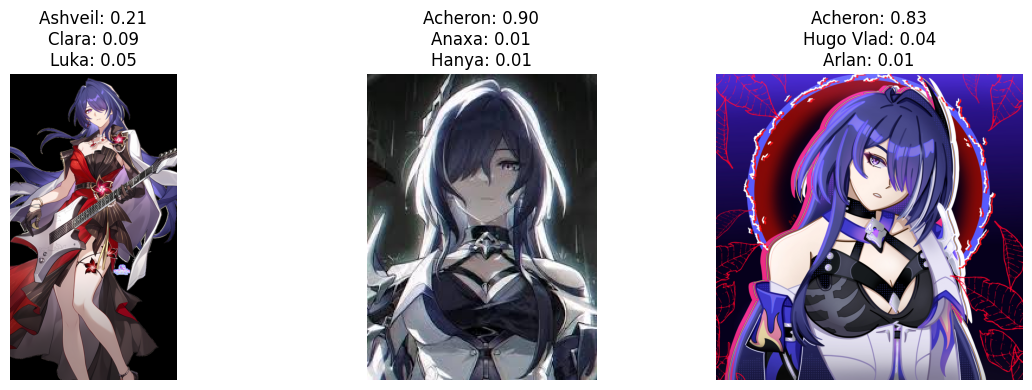

In [ ]:
import torch
from torchvision import transforms, models
from PIL import Image
import json
import torch.nn as nn
import matplotlib.pyplot as plt


# Load classes

with open("classes.json", "r") as f:
    classes = json.load(f)

num_classes = len(classes)


# Load model

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model.load_state_dict(torch.load("model.pth"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


# Image transform

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


# Predict in an attempt to classify

def predict_top3(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)

        top3 = torch.topk(probs, 3)

    results = []
    for i in range(3):
        idx = top3.indices[0][i].item()
        conf = top3.values[0][i].item()
        results.append((classes[idx], conf))

    return img, results






#Show results


def show_predictions(image_paths):
    fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 4))

    for i, path in enumerate(image_paths):
        img, results = predict_top3(path)

        title = "\n".join([f"{name}: {conf:.2f}" for name, conf in results])

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(title)

    plt.tight_layout()
    plt.show()


# Test

image_list = ["img1.png", "img2.jpg", "img3.jpg"]
show_predictions(image_list)

As you can see, some of the images that stay very close to the training data and the source material are acurrately classified. This is due to major overfitting instead of proper capture of generalized features. As you can see, the character in her normal outfit is properly classified, but a change in attire made the predictions go completely haywire.

Now I will train a model using the more robust rice dataset.


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
!unzip archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (55).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (550).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5500).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5501).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5502).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5503).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5504).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5505).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5506).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5507).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5508).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5509).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (551).jpg  
  inflating: Rice_Image_Dataset/Karacadag/Karacadag (5510).jpg  
  inflating: Rice_Image_Dataset/Karacadag/K

In [ ]:
#The Images have specific classes, however they haven't been sepearated into training and test images, which we need to do

!pip install split-folders[full]
import splitfolders


# Ratio: train, test

splitfolders.ratio("Rice_Image_Dataset", output="output", seed=1337, ratio=(.8, .2), group_prefix=None)


Copying files: 75000 files [00:11, 6339.52 files/s]


In [ ]:
#Now we can prepare the CNN


train_images = tf.keras.utils.image_dataset_from_directory(
    'output/train'
)

test_images = tf.keras.utils.image_dataset_from_directory("output/val")


#Normalizing pixel values between 0 and 1
train_images = train_images.map(lambda x, y: (x / 255, y))
test_images = test_images.map(lambda x, y: (x / 255, y))

Found 60000 files belonging to 5 classes.
Found 15000 files belonging to 5 classes.


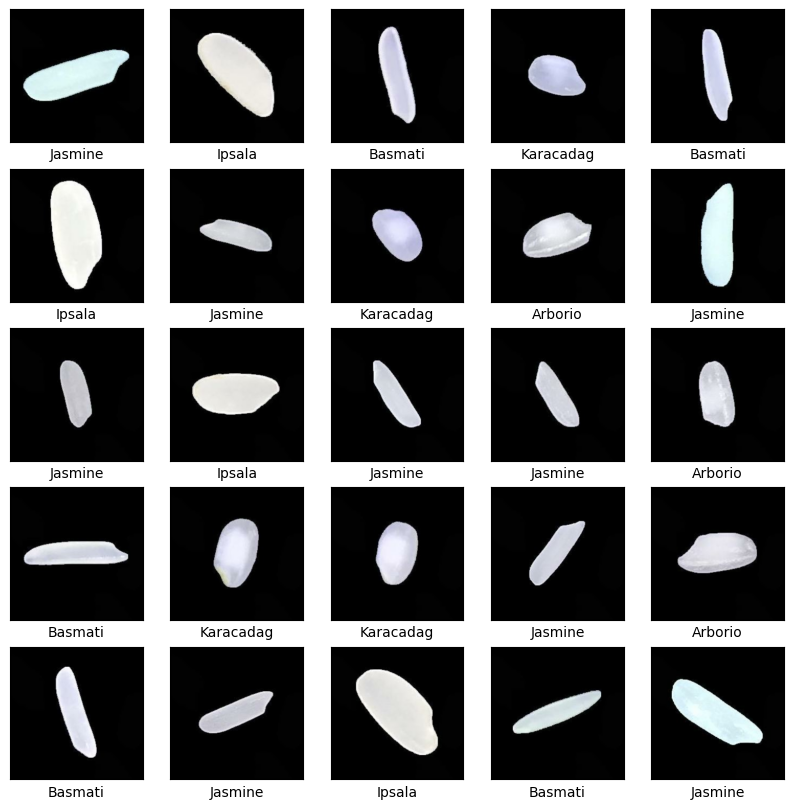

In [ ]:
import matplotlib.pyplot as plt

# Quick verification to see if the data has been imported and normalized correctly

class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

plt.figure(figsize=(10,10))

# Take one batch from the dataset to display images
for images, labels in train_images.take(1):
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i].numpy()) # Convert tensor to numpy array for imshow
        plt.xlabel(class_names[labels[i]]) # Access label directly from the batch
plt.show()

In [ ]:
#Create the convolutional base

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3))) # Changed input_shape to (256, 256, 3)
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Check the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Add dense layers on top


model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(5)) #Amount of output classes


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 230400)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    14,745,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,802,309 (56.47 MB)

 Trainable params: 14,802,309 (56.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Time to compile and train the model!

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, epochs=10,
                    validation_data=test_images)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 132s 65ms/step - accuracy: 0.9601 - loss: 0.1164 - val_accuracy: 0.9734 - val_loss: 0.0773
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 126s 67ms/step - accuracy: 0.9821 - loss: 0.0539 - val_accuracy: 0.9885 - val_loss: 0.0333
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 127s 67ms/step - accuracy: 0.9893 - loss: 0.0337 - val_accuracy: 0.9919 - val_loss: 0.0249
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 67ms/step - accuracy: 0.9926 - loss: 0.0218 - val_accuracy: 0.9902 - val_loss: 0.0320
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 121s 64ms/step - accuracy: 0.9951 - loss: 0.0138 - val_accuracy: 0.9903 - val_loss: 0.0327
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 65ms/step - accuracy: 0.9955 - loss: 0.0131 - val_accuracy: 0.9941 - val_loss: 0.0200
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 121s 64ms/step - accuracy: 0.9963 - loss: 0.0109 - val_accuracy: 0.9941 - val_loss: 0.0222
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 

469/469 - 19s - 41ms/step - accuracy: 0.9921 - loss: 0.0383


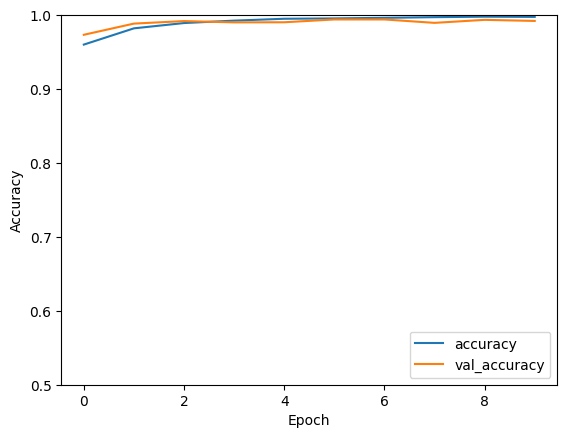

In [ ]:
# Model Evaluation

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images, verbose=2)

As Expected, the dataset with more samples and better variety came out on top. The accuracy reached a whopping 99% percent accuracy across all 5 classes. The simplicity of the samples and the sheer abundance allowed the model to train much more efficiently and throughly than the other model and my custom dataset.